# 5. An entity across a two-month window

SPoRC is a snapshot of **1 May – 30 June 2020**, which rules out long-run
trends. What it does contain is a sharp, precisely dated event — **25 May 2020**,
the killing of George Floyd — sitting almost exactly at the corpus's midpoint
(the median episode date is 28 May). A longer corpus would struggle to give you
that.

That turns "how do podcasts talk about X over time?" from a correlational
question into something closer to a natural experiment: the same shows, the same
hosts, a discontinuity in the middle.

This notebook measures how mention volume and sentiment-in-context shift around
that date.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))     # prefer the source tree
sys.path.insert(0, os.path.dirname(os.path.abspath("_viz.py")))

import sporc
if sporc.__version__ < "1.0":
    raise RuntimeError(
        f"This notebook needs sporc >= 1.0 but imported {sporc.__version__} from "
        f"{os.path.dirname(sporc.__file__)}.\n"
        "PyPI's latest release is 0.2.0, which has a different API, so "
        "`pip install sporc` gets you the wrong one. Install this checkout:\n"
        "    pip install -e /path/to/sporc"
    )

from _viz import apply_style, finish, PALETTE, INK, INK_SECONDARY, INK_MUTED
apply_style()
# Report the location relative to here, so the printed output does not embed
# whoever's home directory this happened to be built in.
print("sporc", sporc.__version__, "from",
      os.path.relpath(os.path.dirname(sporc.__file__)))


sporc 1.1.0 from ../../sporc


In [2]:
from sporc import SPORCDataset

# Built by scripts/make_subset.py; see examples/notebooks/README.md. Kept
# relative so nothing machine-specific leaks into the logged path.
SUBSET = "../../subsets/tutorial"
sporc = SPORCDataset(parquet_dir=SUBSET)
print(sporc)


INFO:sporc.dataset:Initializing Parquet backend from ../../subsets/tutorial


INFO:sporc.parquet_backend:Loading indexes from cache ../../subsets/tutorial/metadata/_index_cache.pkl


INFO:sporc.parquet_backend:ParquetBackend loaded from cache in 0.01s  (403 podcasts, 2,967 episodes)


SPORCDataset(parquet, 403 podcasts, 2967 episodes)


## 5.1 What sentiment-in-context measures

A caution that decides how you read everything below.

**We are measuring sentiment, and calling it a proxy for stance. It is not
stance.** Stance is a speaker's position toward a target — supportive, opposed,
neutral. Sentiment is affective tone. They come apart constantly:

* *"This is a horrifying injustice"* — strongly negative sentiment, **supportive**
  stance toward the victim.
* *"Great, more riots"* — positive words, hostile stance.

For a target like a killing, nearly every mention is negative regardless of the
speaker's politics, so sentiment mostly measures **gravity**, not position. Read
the numbers below as "how negatively charged is the language around this name",
and no further. Real stance detection needs a model trained for it, and usually
human annotation.


In [3]:
import pandas as pd
from datetime import datetime

EVENT = pd.Timestamp("2020-05-25")
TARGETS = {
    "george floyd": ["george floyd", "floyd"],
    "police":       ["police", "policing", "cops"],
    "protest":      ["protest", "protests", "protesters", "protesting"],
    "coronavirus":  ["coronavirus", "covid", "pandemic", "lockdown"],
}

eps = [e for e in sporc.iterate_episodes() if e.has_turn_data and e.episode_date]
print(f"diarized episodes with a date: {len(eps):,}")
dates = pd.Series([e.episode_date for e in eps])
print(f"range: {dates.min():%Y-%m-%d} to {dates.max():%Y-%m-%d}")
print(f"before {EVENT:%d %b}: {(dates < EVENT).sum():,} | on/after: {(dates >= EVENT).sum():,}")


INFO:sporc.parquet_backend:Loading episode DataFrame from feather cache


INFO:sporc.parquet_backend:Loading podcast DataFrame from feather cache


diarized episodes with a date: 2,967
range: 2020-04-30 to 2020-06-29
before 25 May: 1,296 | on/after: 1,671


## 5.2 Finding mentions in context

For each target we take a **context window** of ±25 words around the mention.
The window is a real choice: too tight and you miss the sentence's tone; too wide
and you pick up whatever else was being discussed.


In [4]:
import re
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()
WINDOW = 25

def contexts(text, variants, window=WINDOW):
    """±window words around each variant hit. Whole-word matching only."""
    words = text.split()
    low = [w.lower().strip(".,!?;:'\"") for w in words]
    out = []
    for i, w in enumerate(low):
        if w in variants:
            lo, hi = max(0, i - window), min(len(words), i + window + 1)
            out.append(" ".join(words[lo:hi]))
    return out

rows = []
for e in eps:
    for t in e.turns:
        text = t.text
        low = text.lower()
        for target, variants in TARGETS.items():
            if not any(v in low for v in variants):
                continue                     # cheap prefilter before splitting
            for ctx in contexts(text, set(variants)):
                rows.append({
                    "target": target,
                    "date": e.episode_date,
                    "podcast": e.podcast_title,
                    "category": e.primary_category,
                    "context": ctx,
                    "compound": sia.polarity_scores(ctx)["compound"],
                })

df = pd.DataFrame(rows)
print(f"mention contexts: {len(df):,}")
if len(df):
    df["date"] = pd.to_datetime(df["date"])
    df["day"] = df["date"].dt.floor("D")
    df["after"] = df["date"] >= EVENT
    print(df.groupby("target").agg(n=("compound","size"),
                                   mean_sentiment=("compound","mean")).round(3).to_string())


mention contexts: 7,495
                 n  mean_sentiment
target                            
coronavirus   5875           0.234
george floyd   136          -0.173
police        1051           0.009
protest        433          -0.011


## 5.3 Mention volume

Before sentiment, look at whether anyone is talking about it at all. If the event
did what we think, mention volume should jump on 25 May and stay up.


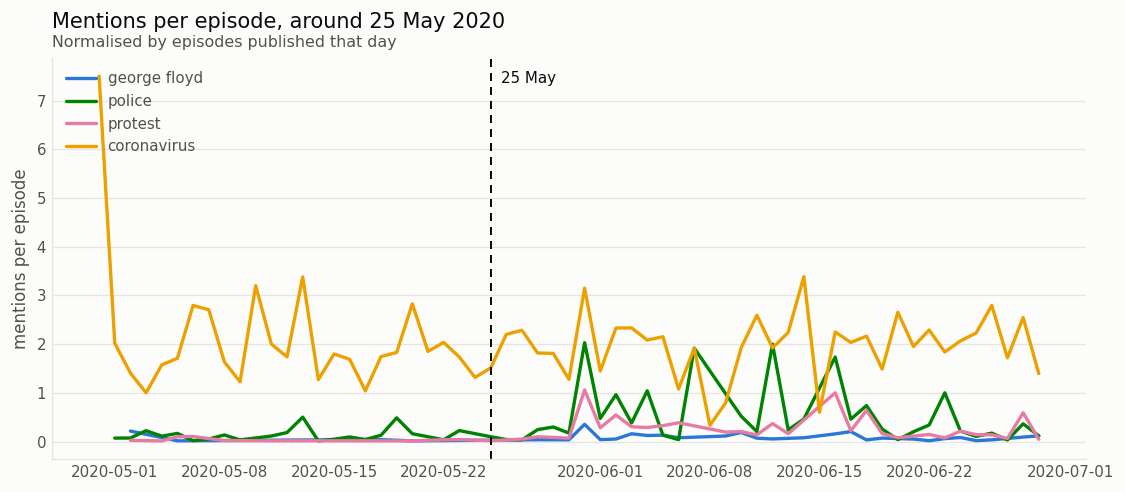

In [5]:
import matplotlib.pyplot as plt

if len(df):
    fig, ax = plt.subplots(figsize=(9.5, 4.2))
    # Fixed slot per target, so a target keeps its colour if the set changes.
    order = list(TARGETS)
    for i, target in enumerate(order):
        sub = df[df.target == target]
        if not len(sub):
            continue
        daily = sub.groupby("day").size()
        # Normalise by episodes that day: raw counts track publishing volume.
        eps_per_day = pd.Series([e.episode_date for e in eps]).dt.floor("D").value_counts()
        rate = (daily / eps_per_day.reindex(daily.index)).dropna()
        ax.plot(rate.index, rate.values, color=PALETTE[i], linewidth=2,
                label=target)

    ax.axvline(EVENT, color=INK, linewidth=1.2, linestyle=(0, (4, 3)))
    ax.annotate("25 May", xy=(EVENT, ax.get_ylim()[1]), xytext=(6, -8),
                textcoords="offset points", fontsize=9, color=INK, va="top")
    ax.legend(loc="upper left")
    finish(ax, title="Mentions per episode, around 25 May 2020",
           subtitle="Normalised by episodes published that day",
           ylabel="mentions per episode")
    plt.show()


## 5.4 Sentiment before and after

Now the tone of the language around each target. Note the y-axis: VADER's
compound score runs −1 (most negative) to +1.


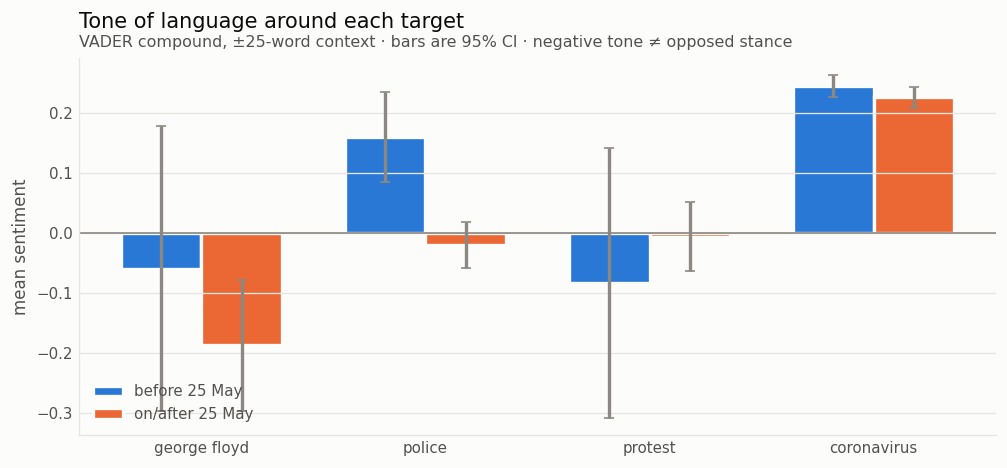

                    size   mean    std
target       after                    
coronavirus  False  2534  0.244  0.473
             True   3341  0.226  0.500
george floyd False    15 -0.060  0.469
             True    121 -0.187  0.615
police       False   174  0.160  0.501
             True    877 -0.020  0.583
protest      False    23 -0.084  0.549
             True    410 -0.007  0.596


In [6]:
import numpy as np

if len(df):
    order = [t for t in TARGETS if (df.target == t).any()]
    fig, ax = plt.subplots(figsize=(8.5, 4.0))
    x = np.arange(len(order))
    w = 0.36
    for j, (flag, label, color) in enumerate([(False, "before 25 May", PALETTE[0]),
                                              (True, "on/after 25 May", PALETTE[5])]):
        means, errs = [], []
        for t in order:
            sub = df[(df.target == t) & (df.after == flag)]["compound"]
            means.append(sub.mean() if len(sub) else np.nan)
            errs.append(sub.sem() * 1.96 if len(sub) > 2 else 0)
        ax.bar(x + (j - 0.5) * w, means, width=w, color=color, label=label,
               yerr=errs, capsize=3, ecolor=INK_MUTED,
               edgecolor="#fcfcfb", linewidth=2)

    ax.axhline(0, color=INK_MUTED, linewidth=1)
    ax.set_xticks(x); ax.set_xticklabels(order)
    ax.legend(loc="lower left")
    finish(ax, title="Tone of language around each target",
           subtitle="VADER compound, ±25-word context · bars are 95% CI · "
                    "negative tone ≠ opposed stance",
           ylabel="mean sentiment")
    plt.show()

    print(df.groupby(["target","after"])["compound"]
            .agg(["size","mean","std"]).round(3).to_string())


## 5.5 Controlling for which shows are talking

A trap: if the mix of *podcasts* changes across the boundary, a sentiment shift
might just be a different set of shows talking. The cleaner comparison holds the
podcast fixed — only shows that discussed the target on **both** sides.


In [7]:
if len(df):
    target = "police" if (df.target == "police").any() else df.target.iloc[0]
    sub = df[df.target == target]
    both = (sub.groupby("podcast")["after"].nunique() == 2)
    keep = both[both].index
    paired = sub[sub.podcast.isin(keep)]

    print(f"target: {target}")
    print(f"podcasts discussing it at all      : {sub.podcast.nunique()}")
    print(f"...on BOTH sides of 25 May         : {len(keep)}")
    if len(keep) >= 3:
        w = (paired.groupby(["podcast","after"])["compound"].mean()
                   .unstack().dropna())
        w.columns = ["before", "after"]
        w["delta"] = w["after"] - w["before"]
        print(f"\nwithin-podcast change: mean {w.delta.mean():+.3f}, "
              f"{(w.delta < 0).sum()}/{len(w)} shows more negative")
        from scipy import stats
        t, p = stats.ttest_rel(w["after"], w["before"])
        print(f"paired t-test: t={t:.2f}, p={p:.3f}")
    else:
        print("\nToo few shows on both sides for a paired test in this subset.")


target: police
podcasts discussing it at all      : 138
...on BOTH sides of 25 May         : 20

within-podcast change: mean -0.259, 16/20 shows more negative
paired t-test: t=-2.21, p=0.040


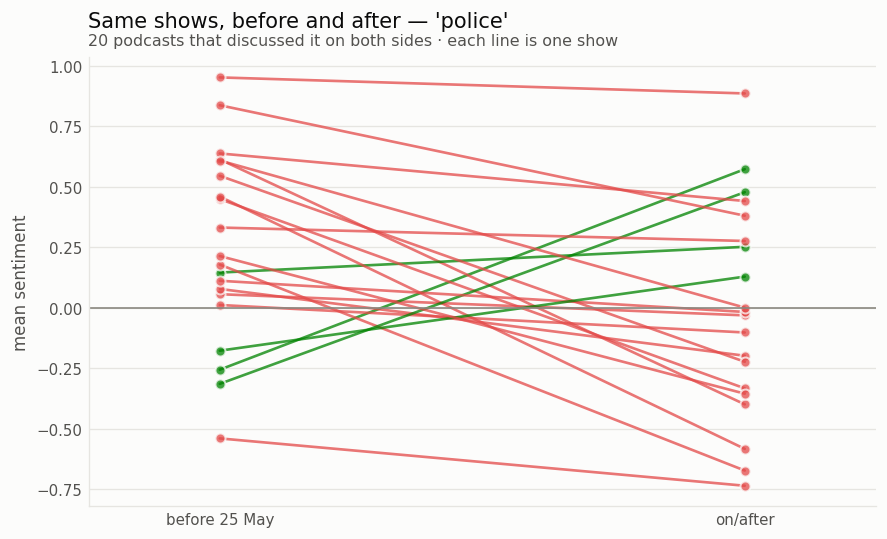

In [8]:
if len(df) and "w" in dir() and len(keep) >= 3:
    fig, ax = plt.subplots(figsize=(7.5, 4.6))
    for pod, r in w.iterrows():
        color = PALETTE[7] if r.delta < 0 else PALETTE[1]
        ax.plot([0, 1], [r.before, r.after], color=color, linewidth=1.6,
                alpha=0.75, marker="o", markersize=6,
                markeredgecolor="#fcfcfb", markeredgewidth=1.2)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["before 25 May", "on/after"])
    ax.set_xlim(-0.25, 1.25)
    ax.axhline(0, color=INK_MUTED, linewidth=1)
    finish(ax, title=f"Same shows, before and after — '{target}'",
           subtitle=f"{len(w)} podcasts that discussed it on both sides · "
                    "each line is one show",
           ylabel="mean sentiment")
    plt.show()


## 5.6 Scope and caveats

**Supported:** mention volume for these targets shifts sharply around 25 May, and
the tone of surrounding language shifts with it — including *within the same
shows*, which rules out the show-mix explanation.

**Not supported:** any claim about what podcasters *think*. Negative tone around
"george floyd" is what you would expect from a supporter and an opponent alike.
This measures gravity, not position.

**Other limits:**

* **VADER is a social-media lexicon.** It was built for tweets, not transcripts.
  It has no idea about irony, quotation, or a host reading an ad.
* **Quotation is invisible.** A host quoting someone else's words gets scored as
  their own.
* **Two months is the whole world here.** There is no "normal baseline" outside
  the window to compare against — only earlier-May versus later-June.
* **Coverage.** Diarized episodes only (~65% of the corpus), so this is a third
  of podcasting, non-randomly selected.
* **Multiple comparisons.** Four targets × several tests. Treat p-values as
  descriptive.

**If you wanted to do this properly:** hand-annotate a few hundred contexts for
stance, fine-tune or few-shot a model against that, and report agreement. The
lexicon is a first look, not a result.
